##### Factors that Lead to Attrition at IBM

The goal of this analysis is to uncover factors that lead to attrition at IBM. Running each cell is this notebook sequentially will allow for reproducing the results.

*Libraries Used*

- Numpy, pandas, and math provide core functionality for working with data and performing calculations.
- Matplotlib and seaborn provide visualization functionality.
- Sklearn, statsmodel, and scipy are used for machine learning.
- Dmba is a supplementary library for machine learning provided by the authors of Data Mining for Business Analytics: Concepts, Techniques, and Applications in Python.

In [1]:
# Core Libraries
import math
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

# Machine Learning
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from mord import LogisticIT
import statsmodels.api as sm
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score

# Textbook Supplementary (dmba)
from dmba.metric import AIC_score
from dmba import classificationSummary
from dmba import gainsChart, liftChart

##### Cost of Attrition

This first block of analysis focuses on understanding and quantifying the cost of attribution. The primary source of research for the cost of attrition is the Society for Human Resource Management website, shrm.org. It is the largest HR professional association in the world.

Many of their resources are behind a paywall, however, the site allows for one free article per month.

References:

- Dyerly, R. (2025, January 21). The myth of replaceability: Preparing for the loss of key employees. SHRM Executive Network. https://www.shrm.org/executive-network/insights/myth-replaceability-preparing-loss-key-employees

In [3]:
# Set global variables for the project

# Create a variable for the dataset file name
dataset_file_name = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

# Load the dataset and calculate annual salary
hr_df = pd.read_csv(dataset_file_name)
hr_df['Annual_Salary'] = hr_df['MonthlyIncome'] * 12

In [4]:
# Quantify the problem

# Get the number of terms and the total annual salary of employees who have left the company
termed_df = hr_df.query('Attrition == "Yes"').copy()
total_terms = termed_df.count().iloc[0]
print(f'Total number of employees who have left the company: {total_terms}')
total_salary_of_temmed_employees = termed_df['Annual_Salary'].sum()
print(f'Total annual salary of employees who have left the company: ${total_salary_of_temmed_employees:,.2f}')

# Get the low estimate of the cost of employee turnover
print('\nLow Estimate of the Cost of Employee Turnover:')
estimated_cost_of_replacing_employees = total_salary_of_temmed_employees * 0.5
print(f'Estimated cost of replacing employees: ${estimated_cost_of_replacing_employees:,.2f}')
avg_replacement_cost_per_employee = estimated_cost_of_replacing_employees / total_terms
print(f'Average cost of replacing each employee: ${avg_replacement_cost_per_employee:,.2f}')

# Get the high estimate of the cost of employee turnover
print('\nHigh Estimate of the Cost of Employee Turnover:'  )
estimated_cost_of_replacing_employees = total_salary_of_temmed_employees * 2
print(f'Estimated cost of replacing employees: ${estimated_cost_of_replacing_employees:,.2f}')
avg_replacement_cost_per_employee = estimated_cost_of_replacing_employees / total_terms
print(f'Average cost of replacing each employee: ${avg_replacement_cost_per_employee:,.2f}')

Total number of employees who have left the company: 237
Total annual salary of employees who have left the company: $13,614,492.00

Low Estimate of the Cost of Employee Turnover:
Estimated cost of replacing employees: $6,807,246.00
Average cost of replacing each employee: $28,722.56

High Estimate of the Cost of Employee Turnover:
Estimated cost of replacing employees: $27,228,984.00
Average cost of replacing each employee: $114,890.23


##### **Phase 1: Problem Statement**

##### Problem Statement

According to the Society for Human Resource Management, the average  replacement cost of an employee can range from 50% to 200% of the employee's annual salary.

Based on those estimates our replacement cost is between 28,722.56  and 114,890.23 dollars per employee for the 237 employees that have left our organization for a total estimated replacement cost between 6,807,246.00  and 27,228,984.00.

Our goal in this study is to understand how factors such as tenure, department, and compensation are associated with employee turnover so that we can identify at employees at risk for leaving the organization so that targeted retention interventions can be deployed.

##### Study Approach

For the study, complementary analytical approaches will be used to identify employees at risk for turnover. First, cluster analysis will be used to segment employees into groups based on the features in the data set to identify underlying employee profiles. Attrition will be reviewed per profile to look for common patterns.

Second, logistic regression modeling will be applied to the dataset to understand which specific factors contribute to attrition. The best performing model will be used to classify which employees are at risk for target intervention.

##### **Phase 2: Data Preprocessing and Exploration**

##### Data Exploration, Cleaning, and Prep

Prior to conducting analysis, the dataset needs to be explored, cleaned, and prepped for analysis.

*Exploration Tasks*

- List the features to understand their types
- Review descriptive statistics for numeric features
- Identify any missing values
- Look for outliers and decide how to handle them
- Look for features that are categorical
- Understand how categories should be ordered for use in analysis

*Clean and Prep Tasks*

- Handle missing values
- Handle outliers
- Reorder categories so most commonly occurring values are first so the coefficients in logistic regression are relative to the reference category (most frequently occuring)
- Create dummies for categorical variables for use in logistic regression
- Scale data for use in clustering

In [5]:
# Get row and column counts. Understanding the size of the dataset is important for 
#   determining which algorithms to use, choosing visualization techniques, 
#   and strategizing how to preprocess the data.

hr_df.shape

(1470, 36)

In [6]:
# Get column names and data types to understand the structure of the dataset 
#   and identify any necessary data type conversions or preprocessing steps.

hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Double check for missing values
hr_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# summary stats — check for outliers via min/max
hr_df.describe()        

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Annual_Salary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,78035.175510
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,56495.481397
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,12108.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,34932.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,59028.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,100548.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,239988.000000


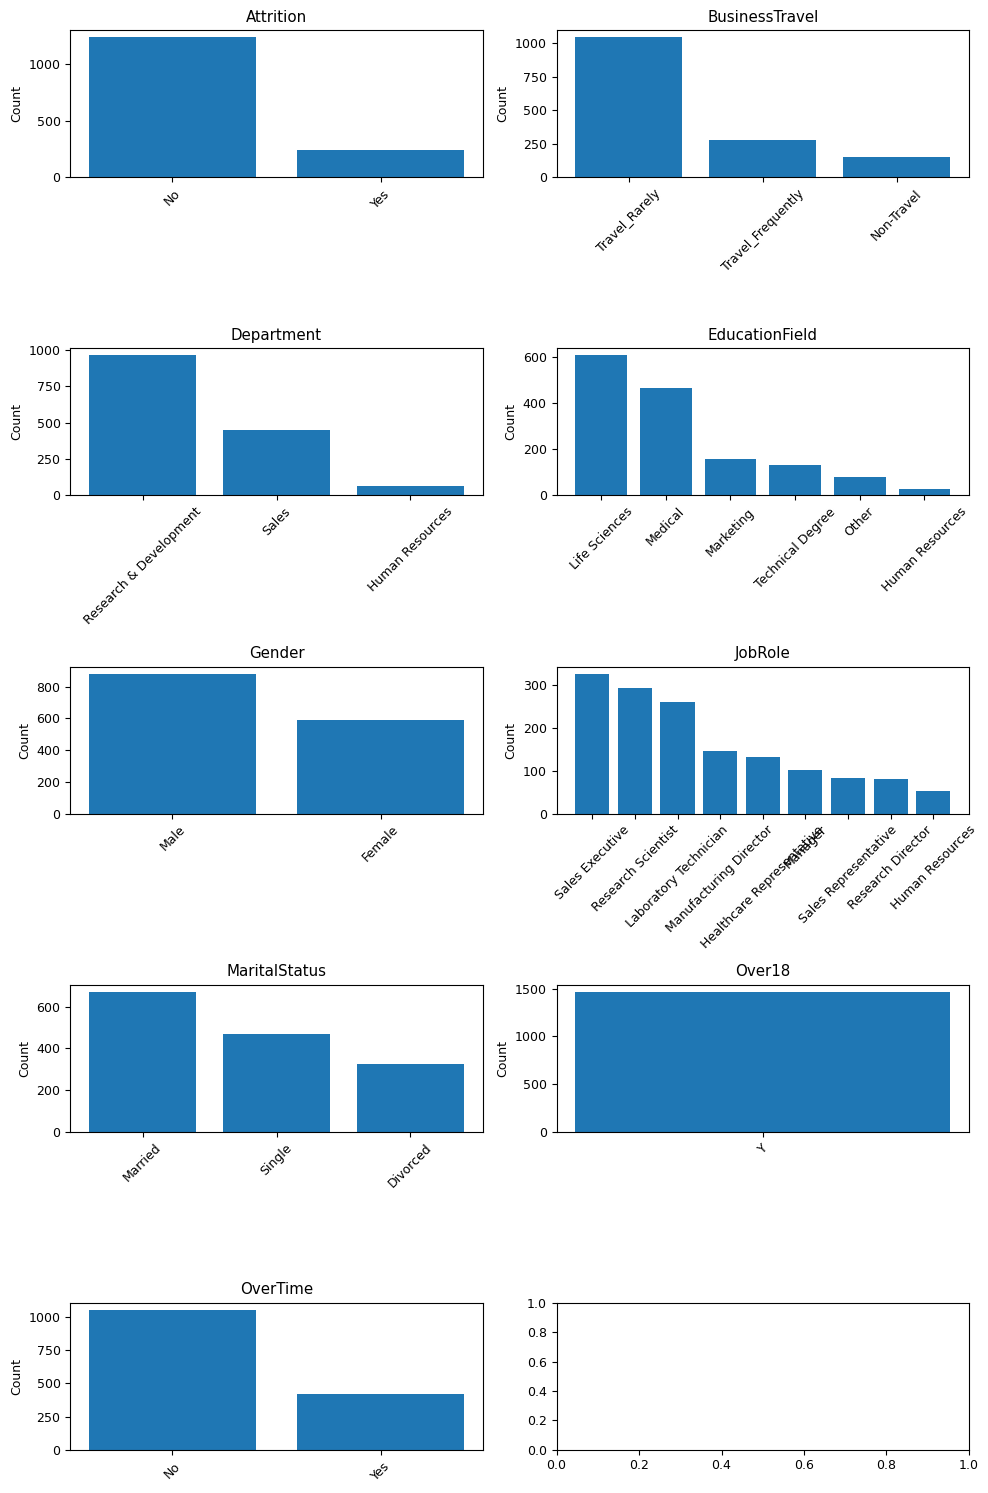

In [9]:
# Look at the categorical variables to understand the distribution of values

# Set all text to 9pt
plt.rcParams['font.size'] = 9

# Select categorical columns and build a 2-column subplot grid
cat_cols = hr_df.select_dtypes(include='object').columns
fig, axes = plt.subplots(5, 2, figsize=(10, 15))

# Pair each subplot (ax) with its corresponding categorical column
for ax, col in zip(axes.flatten(), cat_cols):
    
    # Get value counts and plot as bar chart
    counts = hr_df[col].value_counts()
    ax.bar(counts.index, counts.values)
    
    # Set title, y-axis label, and rotate x-axis ticks
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

*Data Structure Findings*

The data has 1470 rows with 36 columns. There are numerical and object column types. The objects are categorical. There are no missing values.

- No missing values eliminates the need to handle nulls
- 35 potential factors likely require review for variable reduction. All factors may not be applicable. There may also be colinearity among such a high number of variables.
- Objects should be turned into categories and re-ordered from most frequently occurring to least frequently occurring.

*Exploration Findings*

- 1470 rows will make a dendrogram hard to interpret
- Numeric columns don't have values that are non-sensical
- Numeric columns don't have outliers that will impact analysis
- Categorical columns do not have values that need to be cleaned up or merged
- StandardHours is the same for every employee so it will not have an impact in analysis and can be removed.
- Everyone is over 18 so the Over18 feature can be removed.
- Attrition, BusinessTravel, Department, EducationField, Gender, MaritalStatus, JobRole, and OverTime can be turned into categories, reordered, and have dummies created.
- Numeric values are of different magnitudes therefore standardization will be applied for cluster analysis.

*Additional Steps*

- Prior to cluster analysis create a correlation matrix 
- Prior to logistic regression compute VIF scores 

If any features result in multicollinearity, reduce variables accordingly.

##### Clean and Prep the Data

The original dataset will not be modified. A copy of the dataset will be used for analysis, applying the action items listed under the data prep and exploration notes. A standardized dataset will be created for cluster analysis.

In [10]:
# Create a new data frame to hold the cleaned data for modeling
clean_hr_df = hr_df.copy()

# Remove StandardHours and Over18 since they have only one value
clean_hr_df.drop(columns=['StandardHours', 'Over18'], inplace=True)

# Change object data types to category for categorical columns
for col in clean_hr_df.select_dtypes(include='object').columns:
    clean_hr_df[col] = clean_hr_df[col].astype('category')

# Order categories so the most frequent value is the first category for each categorical column
clean_hr_df['Attrition'] = clean_hr_df['Attrition'].cat.reorder_categories(['No', 'Yes'])
clean_hr_df['BusinessTravel'] = clean_hr_df['BusinessTravel'].cat.reorder_categories(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'])
clean_hr_df['Department'] = clean_hr_df['Department'].cat.reorder_categories(['Research & Development', 'Sales', 'Human Resources'])
clean_hr_df['EducationField'] = clean_hr_df['EducationField'].cat.reorder_categories(['Life Sciences', 'Medical', 'Marketing', 'Technical Degree', 'Other', 'Human Resources'])
clean_hr_df['JobRole'] =  clean_hr_df['JobRole'].cat.reorder_categories(['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources'])
clean_hr_df['Gender'] = clean_hr_df['Gender'].cat.reorder_categories(['Male', 'Female'])
clean_hr_df['MaritalStatus'] = clean_hr_df['MaritalStatus'].cat.reorder_categories(['Married', 'Single', 'Divorced'])   
clean_hr_df['OverTime'] = clean_hr_df['OverTime'].cat.reorder_categories(['No', 'Yes'])

# Get dummy variables for categorical columns
clean_hr_df = pd.get_dummies(clean_hr_df, prefix_sep='-', drop_first=True, dtype=int)

cluster_features = ['EmployeeNumber','Age','DailyRate','DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
reduced_hr_df = clean_hr_df[cluster_features]
reduced_hr_df.set_index('EmployeeNumber', inplace=True)

#Set Index to EmployeeNumber since it is a unique identifier for each employee
clean_hr_df.set_index('EmployeeNumber', inplace=True)
hr_df.set_index('EmployeeNumber', inplace=True)

##### **Phase 3: Machine Learning Models**

##### Cluster Analysis

1. Standardize the data
2. Check for multicollinearity using a correlation matrix
3. Reduce features if necessary
4. Perform agglomerative cluster analysis and choose the best model based on dendrograms, heatmaps, centroids, and sihouette scores
5. Perform K-means cluster analysis and compare the results to the best agglomerative model
6. Cross-validate agglomerative and K-means analysis, checking if they agree
7. Summarize attrition by cluster assignments

*Cluster Analysis Step 1 - Standardize the Data*

In [11]:
# Standardize the data using z-score scaling (mean = 0, std = 1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit and transform the reduced dataset, preserving column names
normed_hr_df = pd.DataFrame(scaler.fit_transform(reduced_hr_df), columns=reduced_hr_df.columns)

# Preserve the original index
normed_hr_df.index = reduced_hr_df.index

*Cluster Analysis Step 2 - Check for Multicollinearity*

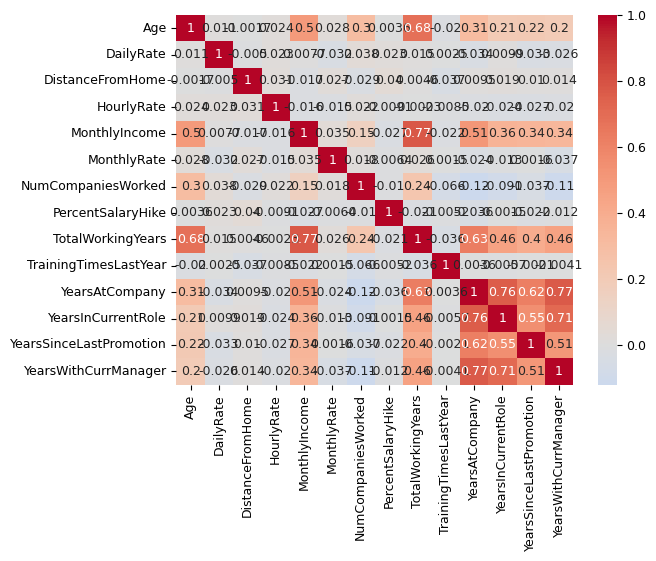

In [12]:
# Compute the correlation matrix on the standardized data
correlation_matrix = normed_hr_df.corr()

# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

*Cluster Analysis Step 3 - Reduce Features*

Correlation Matrix Findings

- YearsWithCurrManager and YearsAtCompany are close to the 0.8 threshold (0.77).
- YearsWithCurrManager and YearsInCurrentRole are close to the 0.8 threshold (0.71).

Decision

- Proceeding without removing any features. If the downstream analysis is negatively impacted, this decision will be revisited.

*Cluster Analysis Step 4 - Agglomerative Cluster Analysis*

1. Create dendrograms for different linkage methods
2. Identify methods with meaningful cluster assignments
3. Review heatmaps of of linkage methods with meaningful cluster assignments
4. Review centroids
5. Review silhouette scores

*Dendrograms*

Create a function that takes in the data, the linkage method, and the threshold so that the code doesn't have to be repeated multiple time.

In order to handle the large number of rows in the dendrogram, truncating will be used. Code for truncating the dendrogram is based on the following blog post:

Hees, J. (2015, August 26). SciPy hierarchical clustering and dendrogram tutorial. Jörn's Blog. https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/

In [13]:
# Plot dendrograms for different linkage methods
def plot_dendrogram(df, method, color_threshold):
    """
    Plots a truncated hierarchical clustering dendrogram.
    
    Parameters:
    -----------
    method : str — linkage method ('single', 'complete', 'average', 'weighted', 'centroid', 'median', 'ward')
    """
    Z = linkage(df, method=method)

    plt.figure(figsize=(14, 6))
    dendrogram(
        Z,
        # Instead of showing all of the details of the dendrogram, 
        #   collapse to show a summary
        truncate_mode='lastp',
        p=30,
        show_contracted=True,
        color_threshold=color_threshold
    )
    plt.title(f'Hierarchical Clustering Dendrogram — {method.capitalize()} Linkage')
    plt.xlabel('Cluster Size')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()

Run the function for each linkage method and review the outputs.

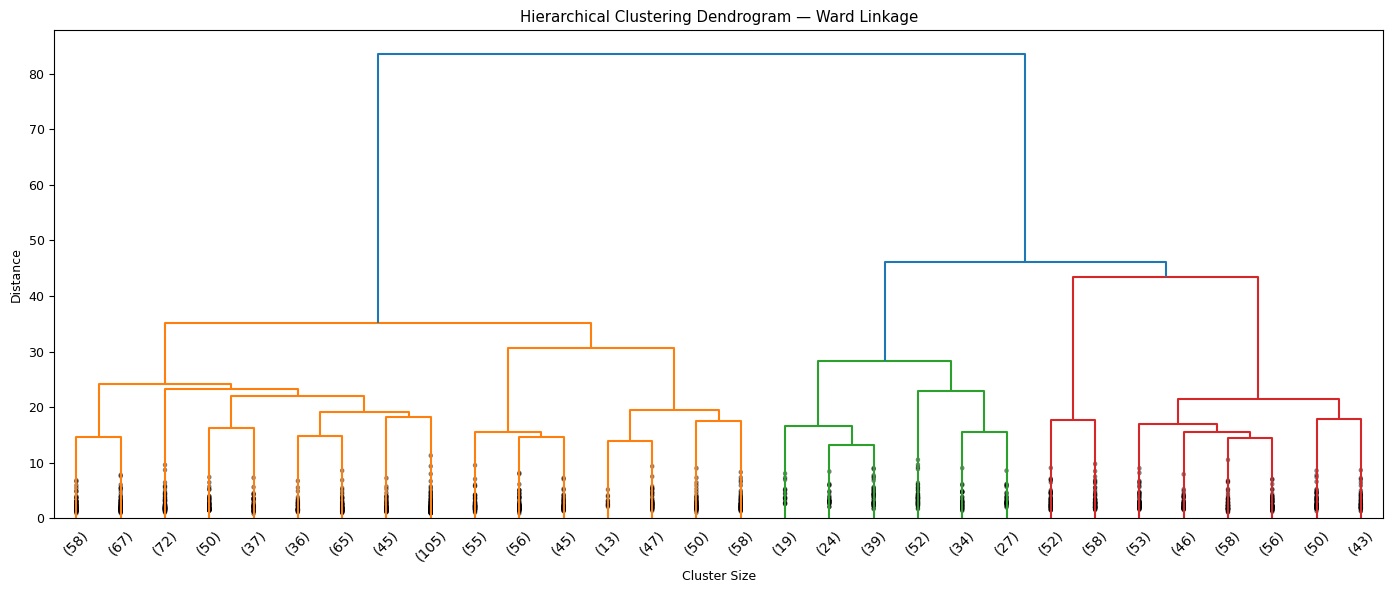

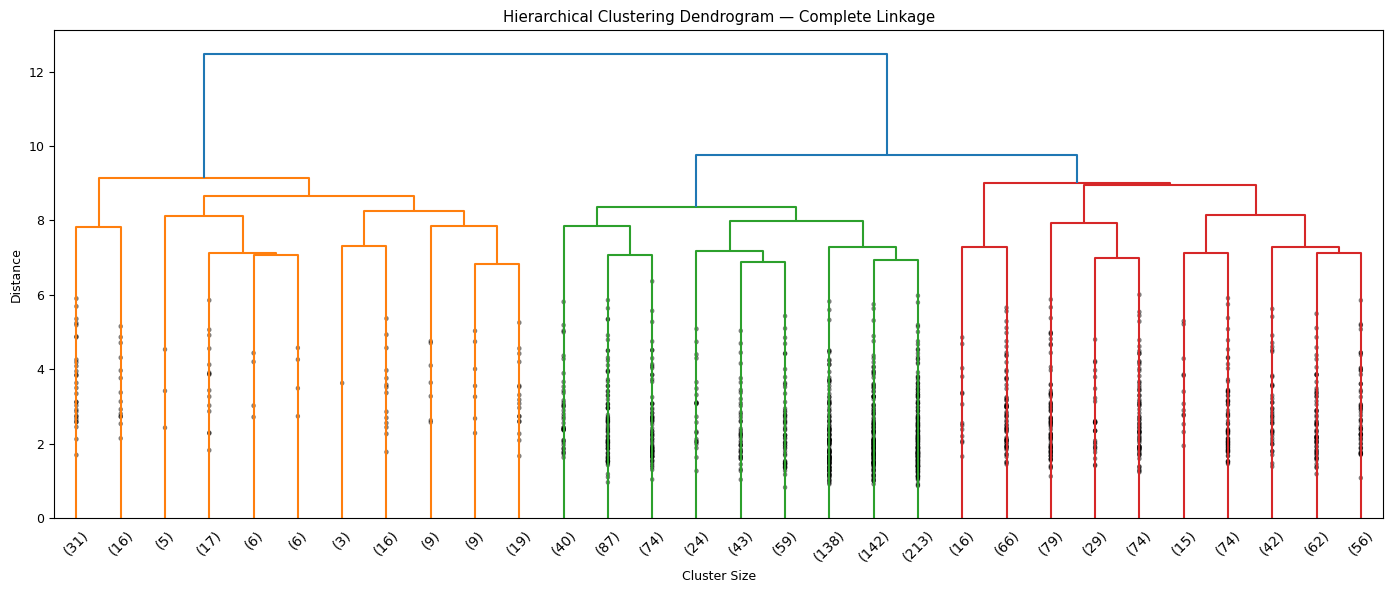

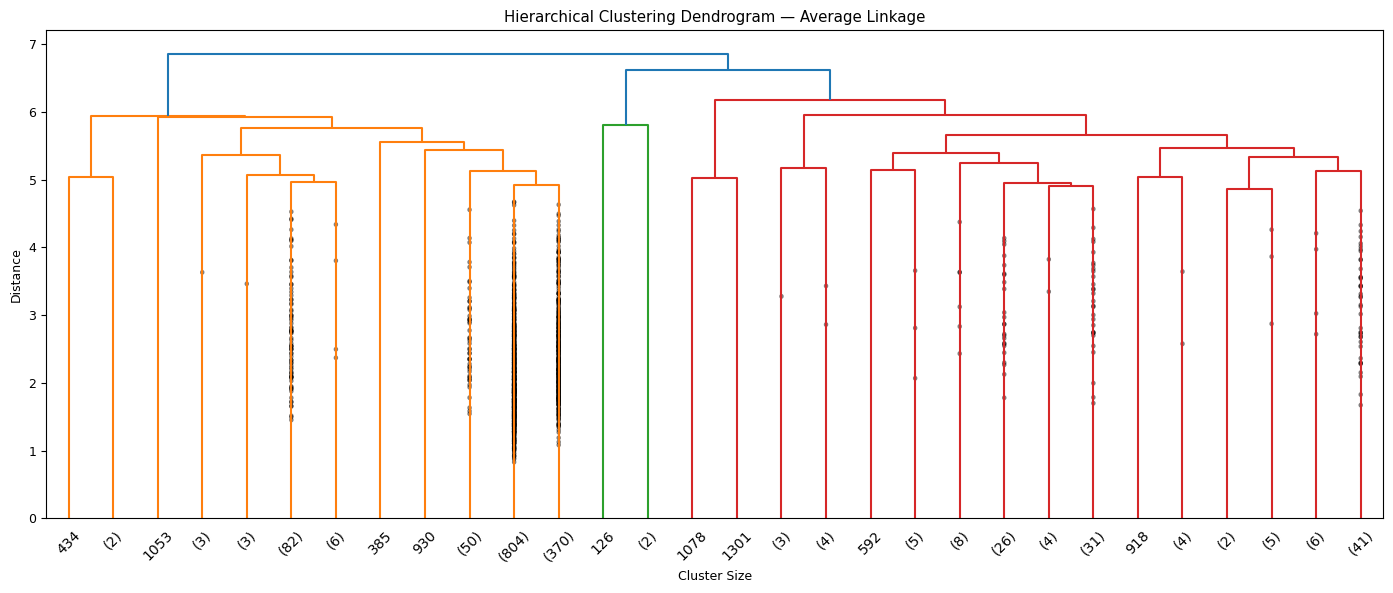

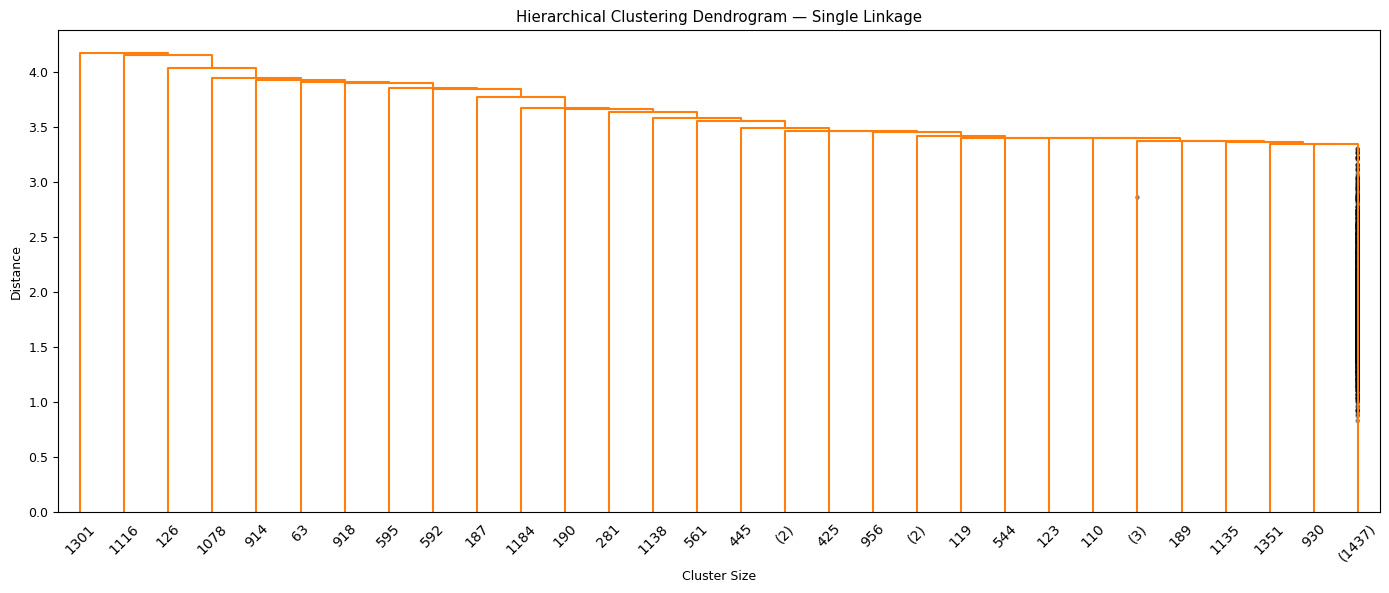

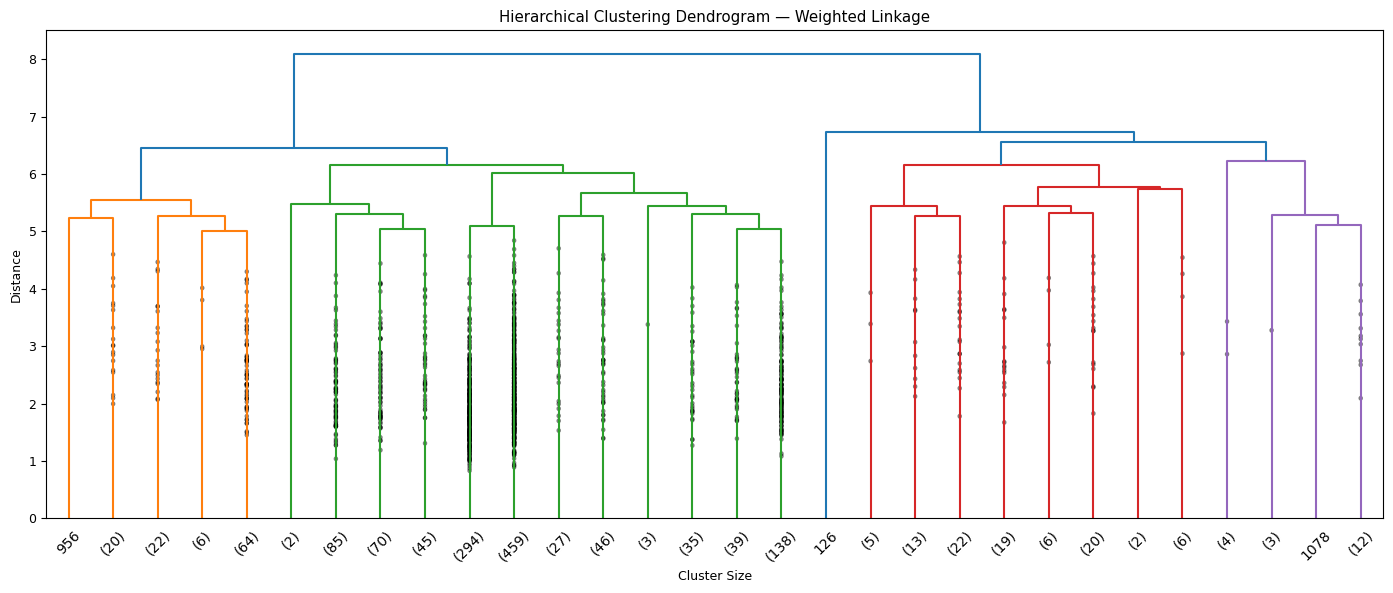

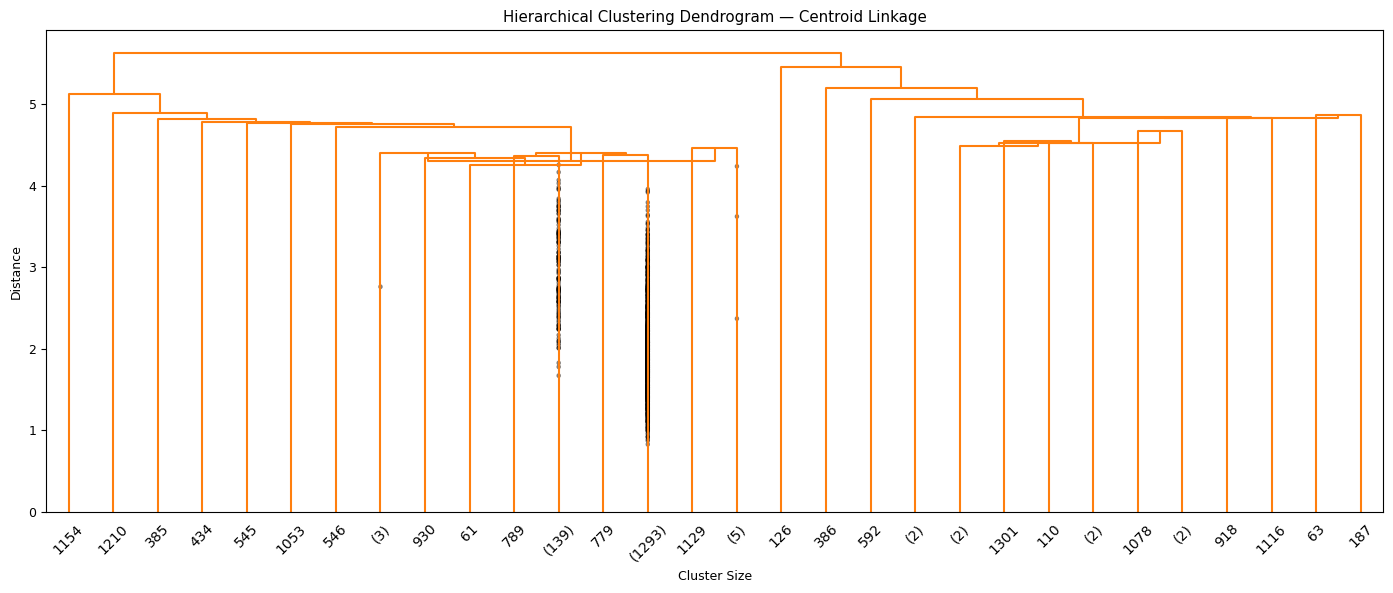

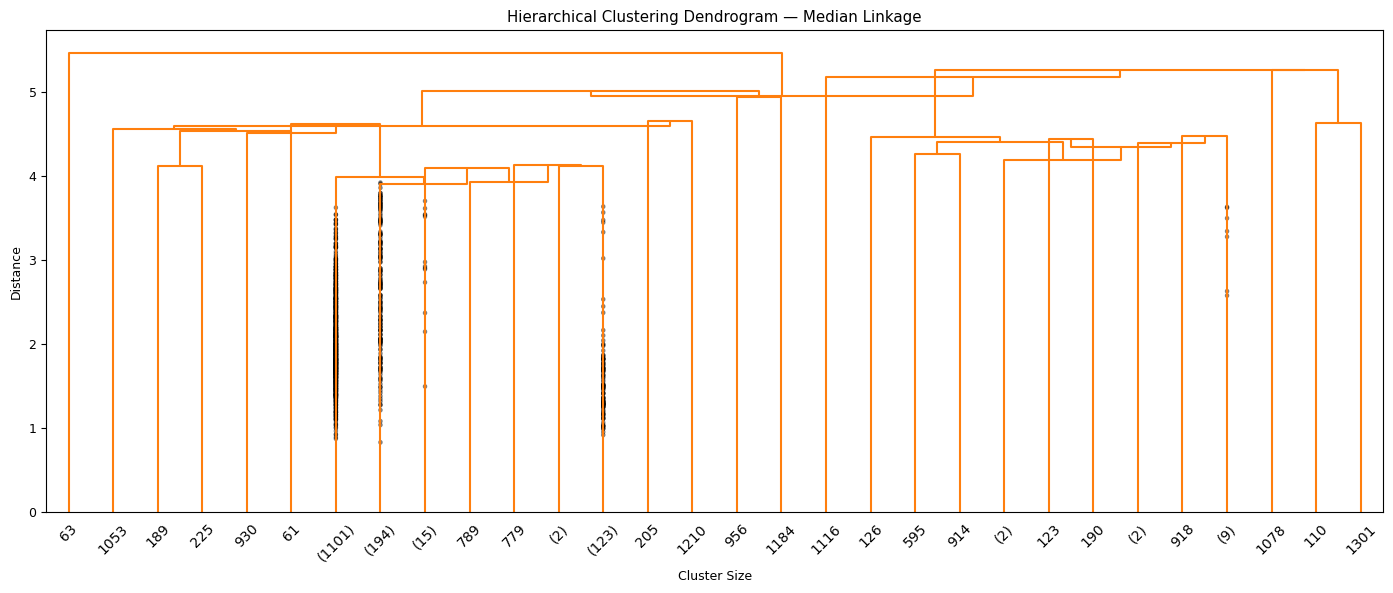

In [14]:
# Compare all linkage methods to evaluate cluster structure
# color_threshold is tuned per method since each operates on a different distance scale

plot_dendrogram(normed_hr_df, method='ward', color_threshold=45)        # minimizes within-cluster variance — best for compact clusters
plot_dendrogram(normed_hr_df, method='complete', color_threshold=9.5)   # uses maximum distance — good for handling outliers
plot_dendrogram(normed_hr_df, method='average', color_threshold=6.25)   # uses average distance — general purpose
plot_dendrogram(normed_hr_df, method='single', color_threshold=6)       # uses minimum distance — prone to chaining
plot_dendrogram(normed_hr_df, method='weighted', color_threshold=6.25)  # weighted average — balances cluster sizes
plot_dendrogram(normed_hr_df, method='centroid', color_threshold=6)     # uses centroid distance — can produce inversions
plot_dendrogram(normed_hr_df, method='median', color_threshold=6)       # uses median centroid — also prone to inversions

*Review of Dendrograms*

- Median and Centroid do not have branch relationships that roll up cleanly. There are also individual employees on the branches indicating less than meaningful groupings.
- Single linkage also shows individual employee branches and no clear branch structure.
- Ward, Complete, Average, and Weighted have cleaner branch structure, but Average and Weighted have branches with individual employees indicating less than meaningful groupings. A review of heatmaps and silhouette scores for Ward and Complete may help to round out the identification of clusters.

Ward and Complete show good structure with branches that are not overly granular, indicating clusters exist. Additionally, they appear to show 3 clusters.

*Silhouette Scores*

Compute the silouette scores for Ward and Complete linkage to score the clusters.

In [15]:
# Fit Ward linkage agglomerative clustering and compute silhouette score
ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
ward_labels = ward.fit_predict(normed_hr_df)
ward_silhouette = silhouette_score(normed_hr_df, ward_labels)
print(f'Ward Silhouette Score: {ward_silhouette:.4f}')

# Fit Complete linkage agglomerative clustering and compute silhouette score
complete = AgglomerativeClustering(n_clusters=3, linkage='complete')
complete_labels = complete.fit_predict(normed_hr_df)
complete_silhouette = silhouette_score(normed_hr_df, complete_labels)
print(f'Complete Silhouette Score: {complete_silhouette:.4f}')

Ward Silhouette Score: 0.1153
Complete Silhouette Score: 0.1210


*Silhouette Score Review*

The scores are low. This doesn't necessarily invalidate the clusters identified in the dendrogram analysis as it is an overall score. Given the number of features, there may be noise causing a lower score. Moving forward with heatmap review for Ward and Complete linkage. K-means will also serve as a cross-validation reference point.

*Heatmaps for Ward and Complete Linkage*

Heatmaps for both Ward and Complete will be created. A function is used to plot the heatmaps. Analysis will focus on identifying clusters in the heatmaps and a structural review of the dendrograms included on the heatmap.

In [16]:
def plot_clustermap(df, method, n_clusters, cmap='RdYlBu_r'):
    """
    Plots a clustered heatmap with cluster labels on the y-axis.
    
    Parameters:
    -----------
    data       : DataFrame — the normalized data to cluster
    method     : str — linkage method ('ward', 'complete', 'average', 'single')
    n_clusters : int — number of clusters to assign
    cmap       : str — color map for the heatmap
    """
    # Assign cluster memberships using the specified linkage method
    memb = fcluster(linkage(df, method=method), n_clusters, criterion='maxclust')
    memb = pd.Series(memb, index=df.index)

    # Label each row with its cluster assignment
    df.index = ['{}: {}'.format(cluster, state)
                  for cluster, state in zip(memb, df.index)]

    # Plot the clustermap
    sns.clustermap(
        df,
        method=method,
        cmap=cmap,
        yticklabels=False
    )
    plt.title(f'{method.capitalize()} Linkage Heatmap', pad=20)
    plt.show()

*The folowing code produces warnings that have no impact on the analysis*

c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


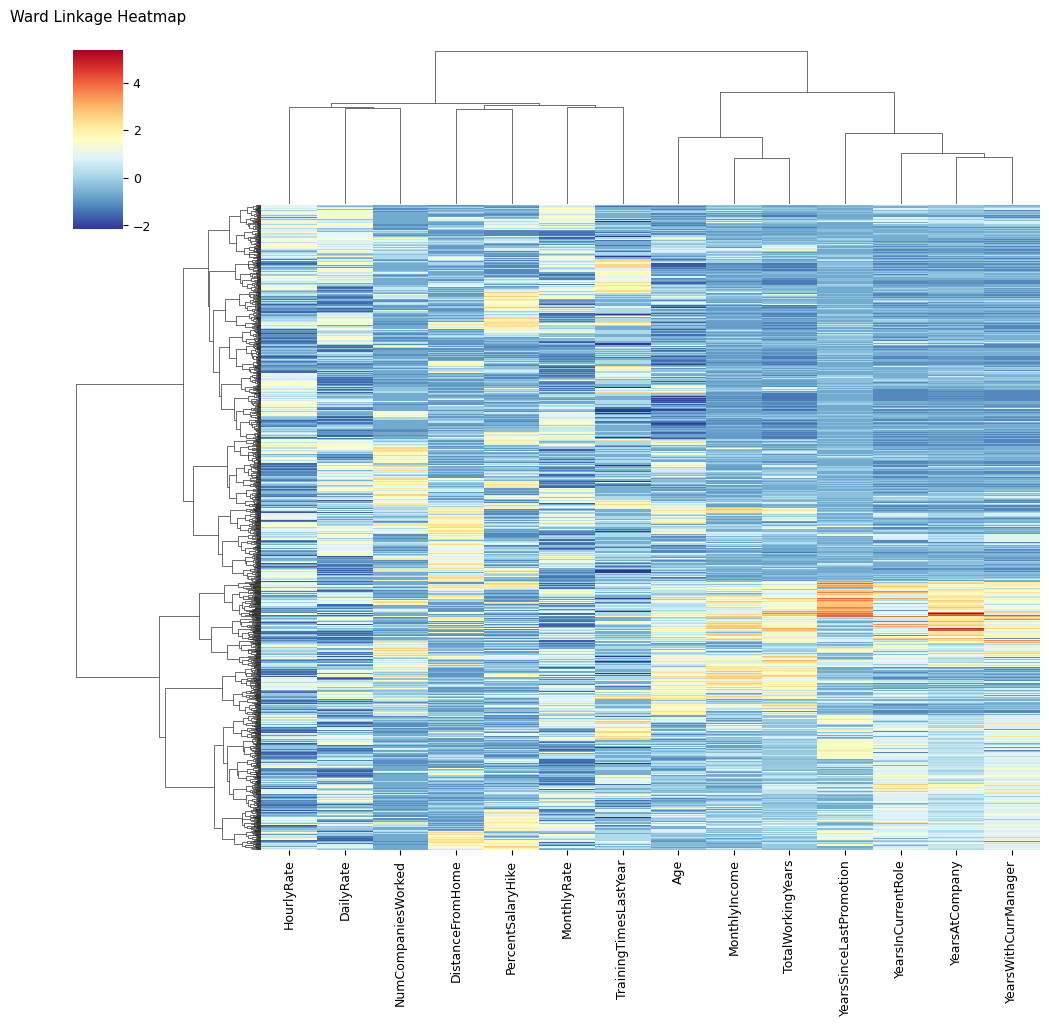

c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


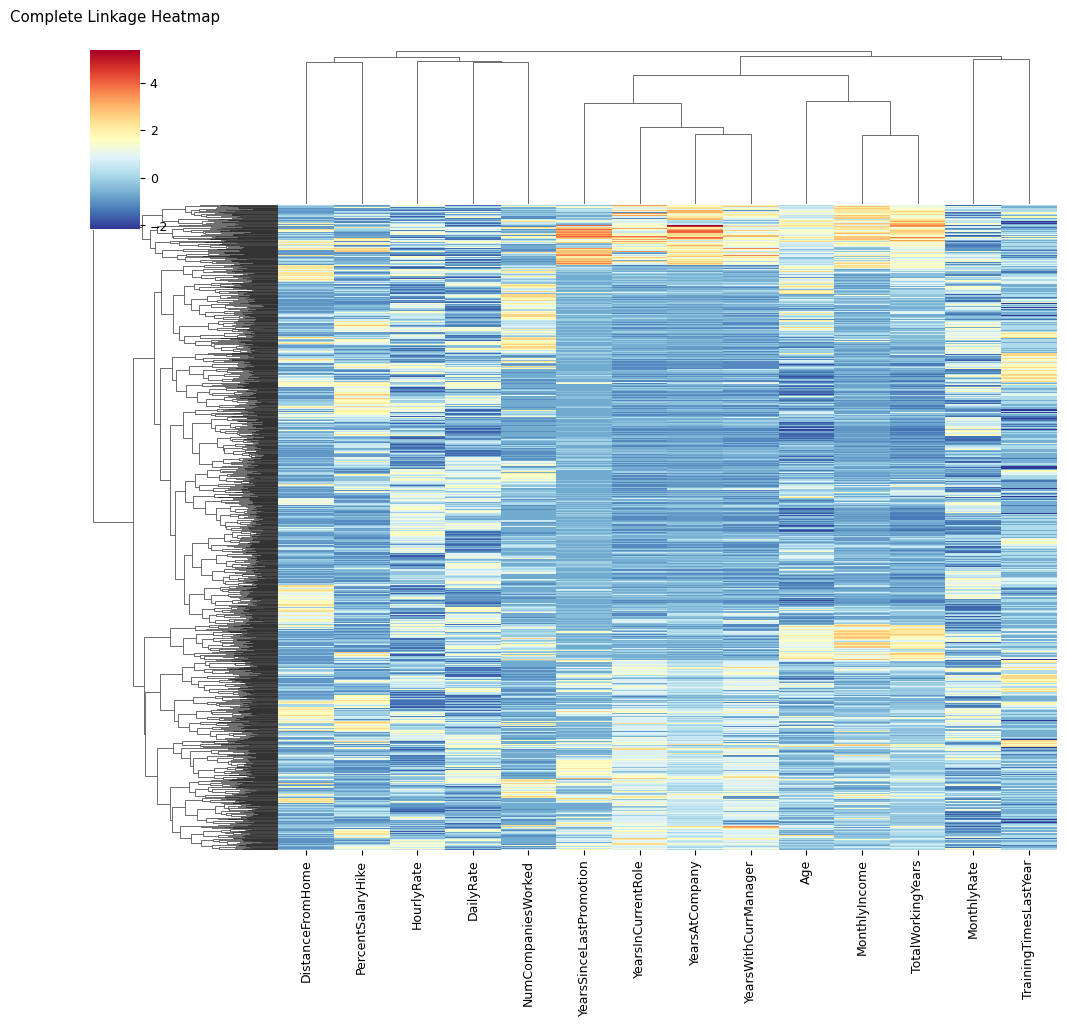

In [17]:
# Plot clustermaps for different linkage methods. Using three clusters since that was the most common number of clusters across the dendrograms.
plot_clustermap(normed_hr_df, method='ward', n_clusters=3)      
plot_clustermap(normed_hr_df, method='complete', n_clusters=3)   

*Review of Heatmaps*

The clusters for employees on the Complete dendrogram are not as clean as the Ward. Both show clusters of employees by age, years at company, and income. Given that Ward's clusters are cleaner it will be used as the agglomerative model.

*Centroids*

Centroid distrances will be calculated and reviewed for Ward linkage and analyzed to further understand any underlying clusters.

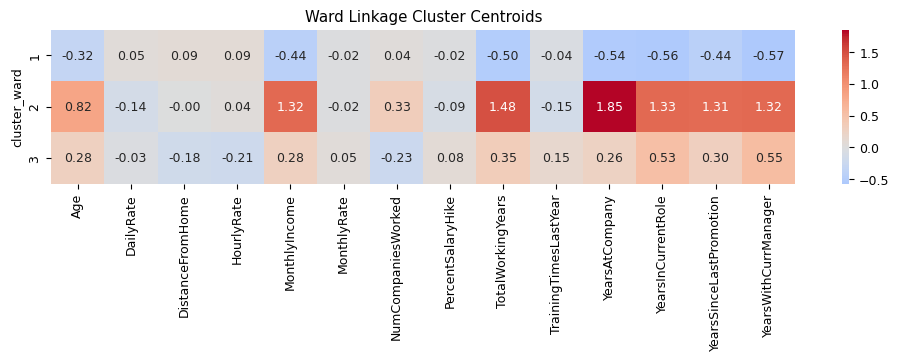

In [18]:
# Decide on number of clusters
n_clusters = 3
centroid_normed_df = normed_hr_df.copy()

# Build linkage matrices for ward and complete
linkage_ward = linkage(centroid_normed_df, method='ward')

# Get cluster assignments
clusters_ward = fcluster(linkage_ward, n_clusters, criterion='maxclust')

# Add cluster assignments to dataframe
centroid_normed_df['cluster_ward'] = clusters_ward

# Calculate centroids (means) for each cluster
centroids_ward = centroid_normed_df.groupby('cluster_ward').mean()

# Plot centroid heatmap
plt.figure(figsize=(12, 2)) 
sns.heatmap(centroids_ward, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Ward Linkage Cluster Centroids')
plt.show()

*Centroid Review*

Based on a review of the centroids, it appears that the three clusters are segmented by age, monthly income, total work experience, and time with the company.

- Cluster 1 - younger employees with lower salaries, less overall experience, and less tenure with the company compared to the other clusters.
- Cluster 2 - older employees with highest salaries, the most experience, and the most tenure compared to other clusters.
- Cluster 3 - the middle tier regarding age, salary, experience, and tenure compared to the other two groups.

Cluster 1 appears to be junior employees, cluster 2 appears to be senior employees, and cluster 3 are mid-career employees.

*Cluster Analysis Step 5 - K-Means Analysis*

K-Means will be used to cross validate the agglomerative models and provide additional insight that may not be evident from the aggolmerative models.

1. Identify number of clusters. Compare to agglomerative models.
2. Fit the model.
3. Review and plot centroids. Compare to agglomerative models.
4. Review silhouette scores.
5. Review distance to cluster centers.
6. Summarize findings and cross-validation with agglomerative models.

*Identify number of clusters*

Using an elbow plot, identify the optimal number of clusters for K-means.

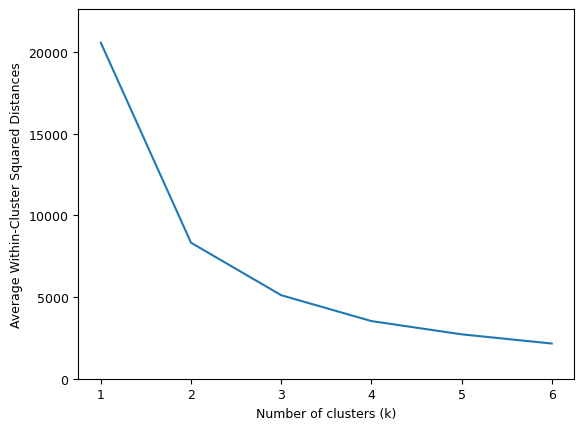

In [19]:
# Compute average within-cluster squared distances for k=1 to k=6
inertia = []
for n_clusters in range(1, 7):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(normed_hr_df)
    inertia.append(kmeans.inertia_ / n_clusters)  

# Build a dataframe of inertia values for plotting
inertias = pd.DataFrame({'n_clusters': range(1, 7), 'inertia': inertia})

# Plot the elbow curve to identify the optimal number of clusters
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))  
ax.legend().set_visible(False)
plt.show()

*K-means Cluster Count*

Based on the elbow plot, the distance within clusters drops substantially between 1, 2, and 3. At cluster 4, the drop in distance is less substantially and the curve starts to flatten out.

Based on the elbow chart and the agglomerative models, three clusters is ideal.

*Fit K-Means Model*

Fit the model to three clusters.

In [20]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(normed_hr_df)
# Cluster membership
memb = pd.Series(kmeans.labels_, index=normed_hr_df.index)

*Plot K-Means Centroids*

Plot the centroids on a heatmap and coordinates plot, review the centroids, and compare to agglomerative models.

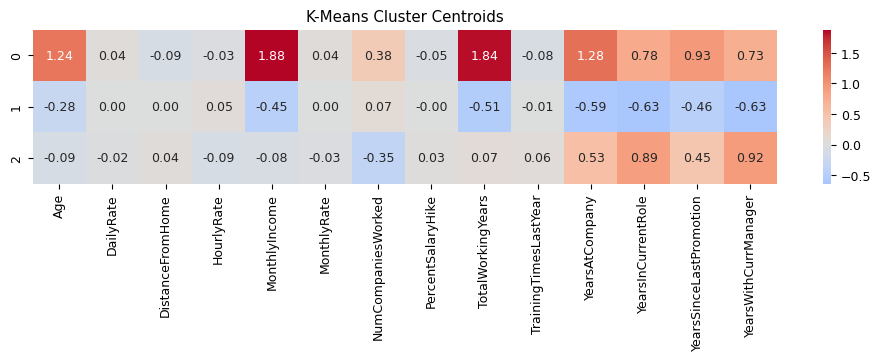

In [21]:
# Plot the centroids of the k-means clusters as a heatmap

centroids_kmeans = pd.DataFrame(kmeans.cluster_centers_, columns=normed_hr_df.columns)
# Plot centroid heatmap
plt.figure(figsize=(12, 2)) 
sns.heatmap(centroids_kmeans, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('K-Means Cluster Centroids')
plt.show()

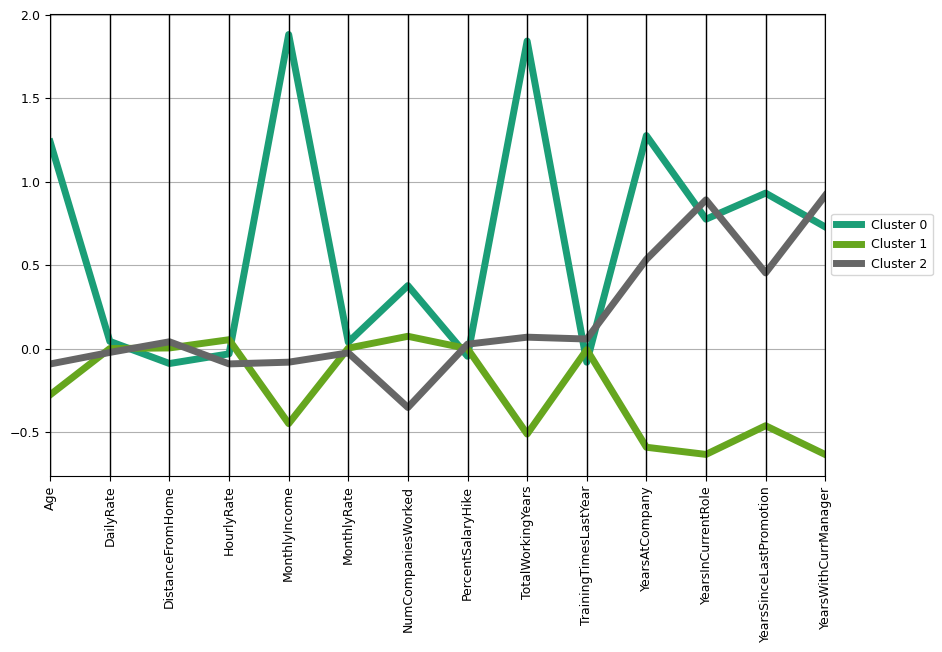

In [22]:
# Plot the centroids of the k-means clusters using parallel coordinates

centroids_kmeans['cluster'] = ['Cluster {}'.format(i) for i in centroids_kmeans.index]
plt.figure(figsize=(10,6))
parallel_coordinates(centroids_kmeans, class_column='cluster', colormap='Dark2', linewidth=5)
plt.xticks(rotation=90)   # vertical
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

*K-Means Centroid Review*

Similar to the agglomerative model, age, income level, experience, and tenure are distinctive features. The clusters line up with the Ward and Complete linkage models. There is an experienced cluster, an inexperienced cluster, and a mid-level experience cluster.

The experienced cluster has similar tenure with the company as the mid-level cluster, however the total years worked and salary are higher. The inexperienced cluster has lower years with the company, lower years in current role, and a lower salary.

*K-Means Silhouette Score Review*

Review the silhouette scores and compare to agglomerative methods.

In [23]:
# K-Means silhouette score
kmeans_silhouette = silhouette_score(normed_hr_df, kmeans.labels_)
print(f'K-Means Silhouette Score: {kmeans_silhouette:.4f}')

K-Means Silhouette Score: 0.1410


The score is similar to that of the agglomerative methods. It is a low score and is likely due to noise. It doesn't necessarily invalidate the classifications.

*K-Means Distance Review*

Compare cluster sizes and distance within cluster.

In [24]:
# calculate the distances of each data point to the cluster centers
distances = kmeans.transform(normed_hr_df)
# find closest cluster for each data point
minSquaredDistances = distances.min(axis=1) ** 2
# combine with cluster labels into a data frame
df = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
    index=normed_hr_df.index)
# group by cluster and print information
for cluster, data in df.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS:.2f} within cluster ')

Cluster 0 (219 members): 3567.95 within cluster 
Cluster 1 (842 members): 7673.89 within cluster 
Cluster 2 (409 members): 4106.08 within cluster 


*K-Means Cluster Distance Review*

Clusters are not evenly distributed. Cluster 1, mid-level employees, has more employees than the other two combined. This indicates that the groups have "soft" boundaries and may not fit cleanly into each cluster. Similar to the silhouette score this is likely influenced by the number of features. Given what the dendrogram and centroid heatmaps reveal, three clusters will continue to be applied. Further refinements can be applied if the three clusters do not provide meaningful insight when analyzing for attrition or for a future iteration of the research.

*Cluster Analysis Step 6 - Cross Validation*

Although the silhouette scores and cluster distances are not ideal, there are meaningful clusters based on the dendrogram and heatmap visualizations for both agglomerative and k-means analysis. A summary of attrition by cluster assignments based on three clusters will be completed to find meaningful insight.

*Cluster Analysis Step 7 - Summarize Attrition by Cluster Assignments*

Cluster assignments for both k-means and Ward linkage will be added back to the original dataset. Charts will be created to summarize attrition by cluster.

*Add labels to the dataset*

In [25]:
# Map Ward cluster numbers to descriptive employee career stage labels
ward_cluster_labels = {
    1: 'Junior',
    2: 'Senior',
    3: 'Mid-Career'
}

# Assign Ward cluster numbers and descriptive labels to the original dataframe
hr_df['cluster_ward'] = clusters_ward
hr_df['cluster_ward_label'] = hr_df['cluster_ward'].map(ward_cluster_labels)

# Map K-Means cluster numbers to descriptive employee career stage labels
kmeans_cluster_labels = {
    0: 'Senior',
    1: 'Junior',
    2: 'Mid-Career'
}

# Assign K-Means cluster numbers and descriptive labels to the original dataframe
hr_df['cluster_kmeans'] = kmeans.labels_
hr_df['cluster_kmeans_label'] = hr_df['cluster_kmeans'].map(kmeans_cluster_labels)

*Summarize Employee Counts by Cluster Assignment*

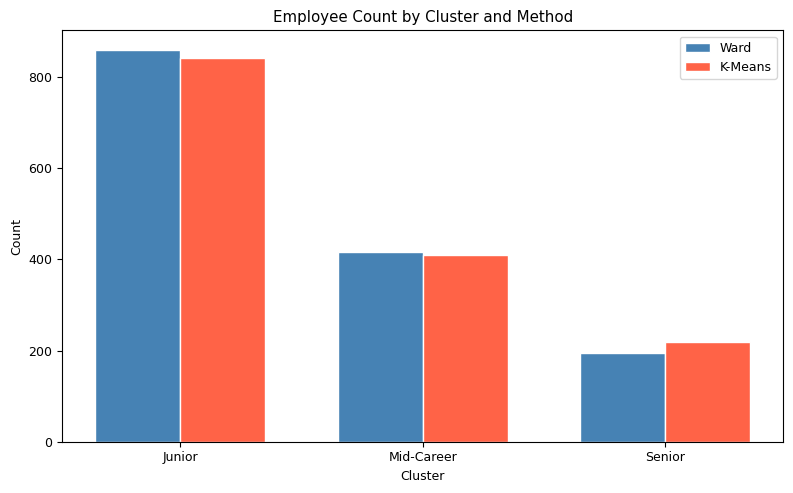

In [26]:
# Calculate employee counts by cluster for each method
ward_counts = hr_df['cluster_ward_label'].value_counts().sort_index()
kmeans_counts = hr_df['cluster_kmeans_label'].value_counts().sort_index()

# Grouped bar chart comparing employee counts by cluster and method
fig, ax = plt.subplots(figsize=(8, 5))

x = range(3)
width = 0.35

# Plot ward and kmeans counts as grouped bars
ax.bar([i - width/2 for i in x], ward_counts.values, width,
       label='Ward', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], kmeans_counts.values, width,
       label='K-Means', color='tomato', edgecolor='white')

ax.set_title('Employee Count by Cluster and Method')
ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(ward_counts.index)   # use ward labels for x axis
ax.tick_params(axis='x', rotation=0)
ax.legend()

plt.tight_layout()
plt.show()

*Review of Employee Counts by Cluster*

Both K-Means and Ward linkage produce very similar cluster assignments. This is an indicator of similarity for the employees assigned to each cluster.

*Summarize Attrition by Cluster Assignment*

Calculate the percent of total attrition by cluster.

Reference:

Moonbooks. (n.d.). How to calculate the fraction in percent of a categorical variable using Pandas GroupBy. https://en.moonbooks.org/Articles/How-to-calculate-the-fraction-in-percent-of-a-categorical-variable-using-GroupBy-on-a-Pandas-DataFrame-/

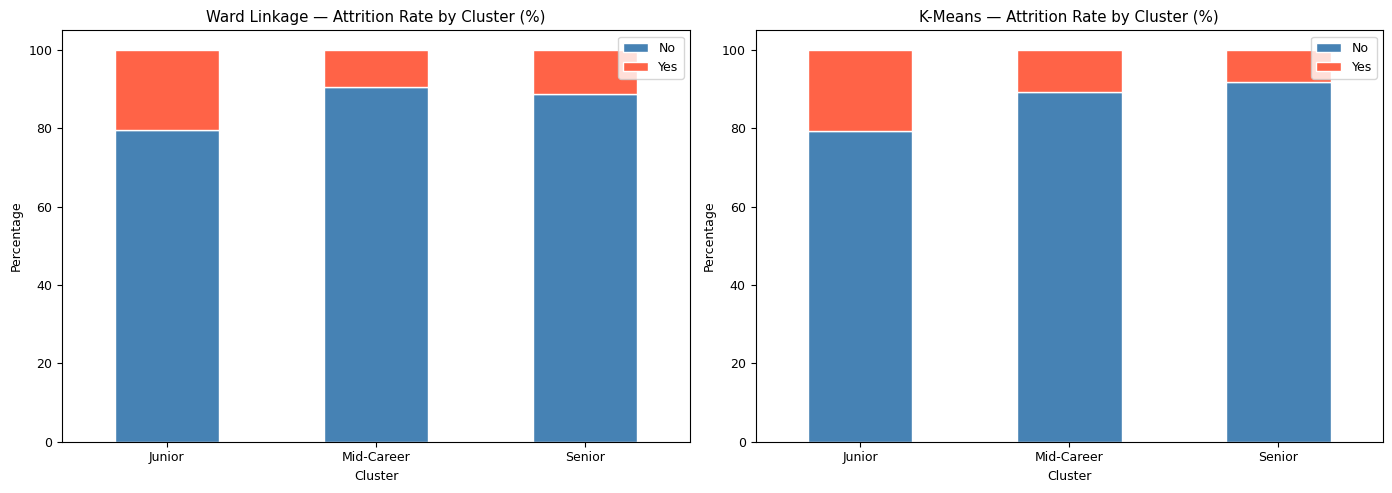

In [27]:
# Calculate attrition rate (%) by cluster — normalize gives proportions, mul(100) converts to percentages
ward_attrition_pct = hr_df.groupby('cluster_ward_label')['Attrition'].value_counts(normalize=True).mul(100).round(1).unstack()
kmeans_attrition_pct = hr_df.groupby('cluster_kmeans_label')['Attrition'].value_counts(normalize=True).mul(100).round(1).unstack()

# Side by side stacked bar charts for ward and kmeans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ward linkage attrition chart
ward_attrition_pct.plot(
    kind='bar',
    stacked=True,                        
    color=['steelblue', 'tomato'],       
    edgecolor='white',
    ax=axes[0]                           
)
axes[0].set_title('Ward Linkage — Attrition Rate by Cluster (%)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=0)  
axes[0].legend(['No', 'Yes'])

# K-Means attrition chart
kmeans_attrition_pct.plot(
    kind='bar',
    stacked=True,                        
    color=['steelblue', 'tomato'],       
    edgecolor='white',
    ax=axes[1]                           
)
axes[1].set_title('K-Means — Attrition Rate by Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)  
axes[1].legend(['No', 'Yes'])

# Adjust spacing and render
plt.tight_layout()
plt.show()

Attrition            No  Yes
cluster_ward_label          
Junior              683  176
Mid-Career          377   39
Senior              173   22
Attrition              No  Yes
cluster_kmeans_label          
Junior                667  175
Mid-Career            365   44
Senior                201   18


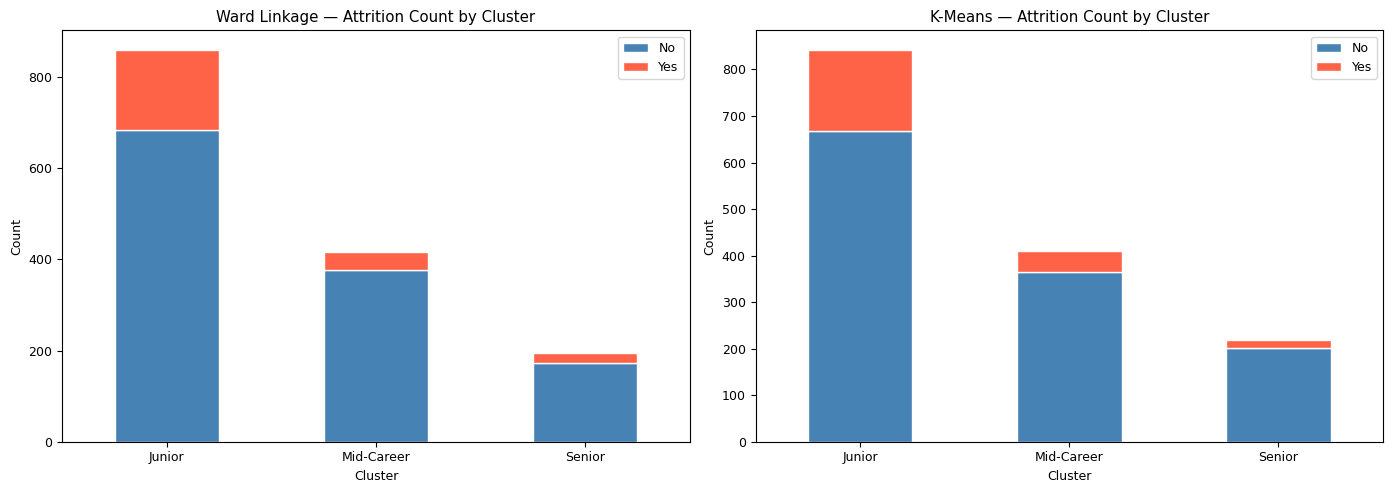

In [28]:
# Calculate attrition count by cluster
ward_attrition_count = hr_df.groupby('cluster_ward_label')['Attrition'].value_counts().unstack()
kmeans_attrition_count = hr_df.groupby('cluster_kmeans_label')['Attrition'].value_counts().unstack()

print(ward_attrition_count)
print(kmeans_attrition_count)

# Side by side stacked bar charts for ward and kmeans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ward linkage attrition count chart
ward_attrition_count.plot(
    kind='bar',
    stacked=True,
    color=['steelblue', 'tomato'],
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_title('Ward Linkage — Attrition Count by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No', 'Yes'])

# K-Means attrition count chart
kmeans_attrition_count.plot(
    kind='bar',
    stacked=True,
    color=['steelblue', 'tomato'],
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title('K-Means — Attrition Count by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No', 'Yes'])

plt.tight_layout()
plt.show()

*Cluster Analysis Conclusion*

Junior level employees have the highest risk for attrition. They represent roughly 175 employees at risk. They should be targeted for retention interventions.

##### Logistic Regression - Find Out What is Driving Turnover

A logistic regression model will be developed to identify factors driving turnover. Before running the analysis, variance inflation factors will be reviewed to identify multicollinearity.

1. Check for multicollinearity
2. Fit logistic model and evaluate. Review confusion matrix for predictive power. Assess precision, recall, and specificity.
3. Identify factors leading employees to leave or stay.
4. Identify employees at risk for turnover.

Risk will be assessed based on a 50% cutoff. If too many at-risk employees are missed, it can be lowered. The cost of intervention is likely less than the cost of replacement, so cost of spending effort on retaining employees that were not likely to leave is lower than the cost of losing employees.

*Logistic Regression Step 1 - Check for Multicollinearity*

Compute VIF for each factor. Review for high VIF and potentially reduce factors.

In [29]:
# VIF requires numeric data only — no categoricals
num_cols = normed_hr_df.select_dtypes(include='number').columns
X = normed_hr_df[num_cols].dropna()

# Calculate VIF for each variable
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF descending to see worst offenders first
vif.sort_values('VIF', ascending=False)

,Variable,VIF
8,TotalWorkingYears,4.645708
10,YearsAtCompany,4.563884
13,YearsWithCurrManager,2.748080
11,YearsInCurrentRole,2.684841
4,MonthlyIncome,2.528796
0,Age,1.989844
12,YearsSinceLastPromotion,1.668993
6,NumCompaniesWorked,1.243004
1,DailyRate,1.010157
5,MonthlyRate,1.007865


*VIF Review*

Most of the values are less than two. Income is 2.5 and the tenure and exeprience variables range from 2.6 to 4.7. This is consistent with the cluster analysis findings. As all values are moderate, no factors will be removed.

*Logistic Regression Step 2 - Fit the Model and Assess It*

Break the data up into a training and validation set, fit the model, and run assessments such as confusion matrix and precision, recall, and specificity.

*Break Up the Data Into Training and Validation Sets*

In [30]:
# Define features and target
X_1 = clean_hr_df.loc[:, clean_hr_df.columns != 'Attrition-Yes']
y_1 = clean_hr_df['Attrition-Yes']

# Split into training and validation sets using standard train/test split
train_X_1, valid_X_1, train_y_1, valid_y_1 = train_test_split(
    X_1, y_1, test_size=0.4, random_state=1
)

*Fit the Model*

*The folowing code produces warnings that have no impact on the analysis*

In [31]:
# fit a logistic regression
logit_reg_1 = LogisticRegression(penalty='l2', C=1e24, solver='lbfgs', multi_class='multinomial', max_iter=10000)
logit_reg_1.fit(train_X_1, train_y_1)

c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+24
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'multinomial'


*Run Confusion Matrix*

In [32]:
# training confusion matrix
classificationSummary(train_y_1, logit_reg_1.predict(train_X_1))

# validation confusion matrix
classificationSummary(valid_y_1, logit_reg_1.predict(valid_X_1))

Confusion Matrix (Accuracy 0.8968)

       Prediction
Actual   0   1
     0 731  16
     1  75  60
Confusion Matrix (Accuracy 0.8588)

       Prediction
Actual   0   1
     0 468  18
     1  65  37


*Run Recall, Specificity, Precision, and the ROC Curve*

Precision: 0.6727272727272727
Recall: 0.3627450980392157
Specificity: 0.9629629629629629


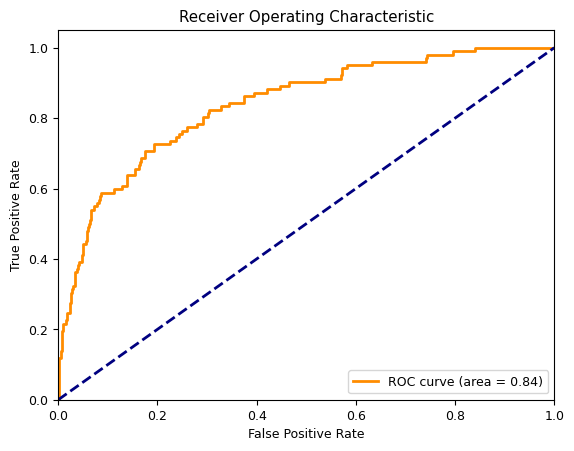

AUC: 0.8384975389332687


In [33]:
# Generate class predictions and predicted probabilities on the validation set
logit_reg_pred = logit_reg_1.predict(valid_X_1)
logit_reg_proba = logit_reg_1.predict_proba(valid_X_1)

# Precision, Recall, and Specificity
precision = precision_score(valid_y_1, logit_reg_pred)
recall = recall_score(valid_y_1, logit_reg_pred)

tn, fp, fn, tp = confusion_matrix(valid_y_1, logit_reg_pred).ravel()
specificity = tn / (tn + fp)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

# Plot ROC Curve and calculate AUC
fpr, tpr, _ = roc_curve(valid_y_1, logit_reg_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f'AUC: {roc_auc}')

*Review of Confusion Matrix, Recall, Specificity, Precision, and ROC Curve*

The model predicts with 86% accuracy on the validation dataset. The model is very accurate at classifying those who will stay (96% specificity). It is right 68% of the time when it flags an employee at risk for attrition (precision). However, it only catches 41% of all employees who leave (recall).

Missing a true flight risk is more costly than a false alarm. Given the low number of attrition observations in the data compared to non-attrition, oversampling will be applied in an attempt to strengthen the model and improve recall.

Oversampling will be attempted using the method as follows:

- First, the response and non-response data are separated into two distinct sets, or strata.
- Records are then randomly selected for the training set from each stratum. Typically, one might select half the (scarce) responders for the training set, then an equal number of non-responders.
- The remaining responders are put in the validation set.
- Non-responders are randomly selected for the validation set in sufficient numbers to maintain the original ratio of responders to non-responders.
- If a test set is required, it can be taken randomly from the validation set.

Reference:
- Shmueli, G., Bruce, P. C., Yahav, I., Patel, N. R., & Lichtendahl, K. C. (2020). Data mining for business analytics: Concepts, techniques, and applications in Python. John Wiley & Sons.

*Break Up the Data Into Training and Validation Sets Based on Oversampling*

In [34]:
# Define features and target
X_2 = clean_hr_df.loc[:, clean_hr_df.columns != 'Attrition-Yes']
y_2 = clean_hr_df['Attrition-Yes']

# Step 1 — separate employees that turned over and those that did not
turned_over_X = X_2[y_2 == 1]
retained_X = X_2[y_2 == 0]
turned_over_y = y_2[y_2 == 1]
retained_y = y_2[y_2 == 0]

# Step 2 — randomly select half of turned over employees for training
train_turned_over_X = turned_over_X.sample(frac=0.5, random_state=1)
train_turned_over_y = turned_over_y[train_turned_over_X.index]

# Step 3 — select equal number of retained employees for training
train_retained_X = retained_X.sample(n=len(train_turned_over_X), random_state=1)
train_retained_y = retained_y[train_retained_X.index]

# Step 4 — combine to create balanced training set
train_X_2 = pd.concat([train_turned_over_X, train_retained_X])
train_y_2 = pd.concat([train_turned_over_y, train_retained_y])

# Step 5 — remaining turned over employees go to validation
valid_turned_over_X = turned_over_X.drop(train_turned_over_X.index)
valid_turned_over_y = turned_over_y[valid_turned_over_X.index]

# Step 6 — sample retained employees for validation to maintain original ratio (~84/16)
valid_retained_X = retained_X.drop(train_retained_X.index).sample(
    n=int(len(valid_turned_over_X) * (len(retained_X) / len(turned_over_X))),
    random_state=1
)
valid_retained_y = retained_y[valid_retained_X.index]

# Step 7 — combine to create validation set
valid_X_2 = pd.concat([valid_turned_over_X, valid_retained_X])
valid_y_2 = pd.concat([valid_turned_over_y, valid_retained_y])

*Fit the Model*

*The folowing code produces warnings that have no impact on the analysis*

In [35]:
logit_reg_50_50 = LogisticRegression(penalty='l2', C=1e24, solver='lbfgs', max_iter=10000, multi_class='multinomial')
logit_reg_50_50.fit(train_X_2, train_y_2)

c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\miniconda3\envs\mds-620\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1e+24
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'multinomial'


*Run Confusion Matrix*

In [36]:
# training confusion matrix
classificationSummary(train_y_2, logit_reg_50_50.predict(train_X_2))

# validation confusion matrix
classificationSummary(valid_y_2, logit_reg_50_50.predict(valid_X_2))

Confusion Matrix (Accuracy 0.8220)

       Prediction
Actual  0  1
     0 99 19
     1 23 95
Confusion Matrix (Accuracy 0.7480)

       Prediction
Actual   0   1
     0 472 147
     1  39  80


*Run Recall, Specificity, Precision, and the ROC Curve*

Precision: 0.3524229074889868
Recall: 0.6722689075630253
Specificity: 0.7625201938610663


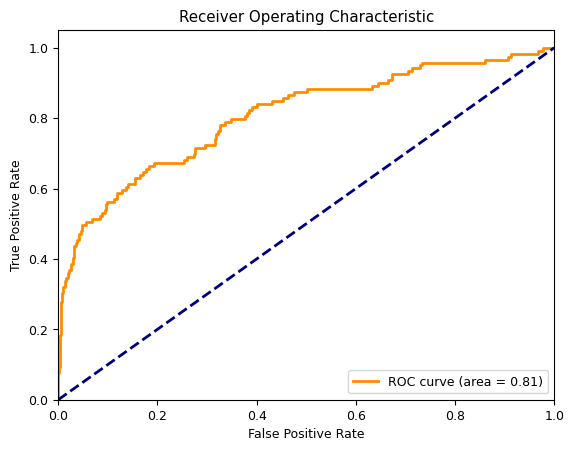

AUC: 0.8065326292067715


In [37]:
# Generate class predictions and predicted probabilities on the validation set
logit_reg_pred = logit_reg_50_50.predict(valid_X_2)
logit_reg_proba = logit_reg_50_50.predict_proba(valid_X_2)

# Precision, Recall, and Specificity
precision = precision_score(valid_y_2, logit_reg_pred)
recall = recall_score(valid_y_2, logit_reg_pred)

tn, fp, fn, tp = confusion_matrix(valid_y_2, logit_reg_pred).ravel()
specificity = tn / (tn + fp)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

# Plot ROC Curve and calculate AUC
fpr, tpr, _ = roc_curve(valid_y_2, logit_reg_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f'AUC: {roc_auc}')

*Review of Confusion Matrix, Recall, Specificity, Precision, and ROC Curve*

This is a better outcome even though the accuracy is lower overall at 75% on the validation dataset. This model catches 68% of those who actually left (recall). Specificity is down to 76% and precision is 35%, but the tradeoff is worth it as the cost associated with intervention is less than replacement as previously stated.

The AUC of 0.81 and steep initial rise of the ROC curve show the model is capturing attrition with low false positive rates.

*Logistic Regression Step 3 - Identify Factors Influencing Empoyee Attrition*

Print out the formula and assess it to find the most influential factors.

In [38]:
# Set final model to the one with better performance on validation metrics 
#   This is so different scenarios can be tested by easily switching the final model 
#   and re-running the rest of the code
final_logistic_model = logit_reg_50_50
final_X = X_2
final_y = y_2

In [39]:
# Build coefficient table with intercept pinned at top, features sorted high to low
coeff_df = pd.DataFrame({
    'Feature': ['Intercept'] + list(final_X.columns),
    'Coefficient': [final_logistic_model.intercept_[0]] + list(final_logistic_model.coef_[0])
}).set_index('Feature').round(4)

# Pin intercept, sort rest
coeff_df = pd.concat([
    coeff_df.loc[['Intercept']],
    coeff_df.drop('Intercept').sort_values('Coefficient', ascending=False)
])


print(coeff_df.to_string())

                                   Coefficient
Feature                                       
Intercept                               0.2159
OverTime-Yes                            1.0226
MaritalStatus-Single                    0.7668
EducationField-Marketing                0.5169
Department-Sales                        0.3988
PerformanceRating                       0.3034
BusinessTravel-Travel_Frequently        0.2916
EducationField-Technical Degree         0.2579
JobRole-Laboratory Technician           0.2578
EmployeeCount                           0.2159
NumCompaniesWorked                      0.1650
JobLevel                                0.1433
JobRole-Sales Representative            0.1318
YearsSinceLastPromotion                 0.1296
EducationField-Human Resources          0.1207
Education                               0.0477
DistanceFromHome                        0.0358
YearsAtCompany                          0.0273
EducationField-Other                    0.0240
HourlyRate   

##### **Phase 4: Model Evaluation Summary**

*Cluster Analysis*

Four models produced sensical clusters. Two of the four, Average and Weighted, included branches with individual employees. Ward and Complete did not exhibit the same behavior, so Average and Weighted were dropped.

Ward and Complete had similar silhouette scores (0.1210 vs 0.1153), however upon review of the heatmaps for both, Ward showed cleaner cluster separation.

The silhouette scores were low, but K-means independently verified the legitimacy of the Ward selection as the cluster numbers (based on dendrogram review for Ward and elbow chart for K-menas) matched and the employees assigned to each cluster were almost identical.

| Metric | Ward Linkage | K-Means |
|--------|-------------|---------|
| Silhouette Score | 0.1153 | 0.1410 |
| Clusters | 3 | 3 |
| Junior Members | 859 | 842 |
| Mid-Career Members | 416 | 409 |
| Senior Members | 195 | 219 |
| Junior Attrition | 176 (20.5%) | 175 (20.8%) |
| Mid-Career Attrition | 39 (9.4%) | 44 (10.7%) |
| Senior Attrition | 22 (11.3%) | 18 (8.2%) |

As such, both K-means and Ward were used in the analysis.

*Logistic Regression*

Two models were evaluated. The first model used a 60/40 training/validation split. The second used oversampling by creating a training set that has 50% attrition and 50% non-attrition.

| Metric | Standard Split | Oversampled |
|--------|---------------|-------------|
| Accuracy | 85.9% | 74.8% |
| Recall | 36.3% | 67.2% |
| Precision | 67.3% | 35.2% |
| Specificity | 96.3% | 76.3% |
| AUC | 0.84 | 0.81 |

Both models had similar AUC scores, with the standard 60/40 split being more accurate at 86% versus 75%. However, the oversampled model had a higher recall score of 67% to 36% for the standard 60/40 split model.

The oversampled model was selected as the final model because of its higher recall score. The rationale is that it is better to identify more employees that actually leave while flagging some who stay as at risk versus better identifying those who will stay while missing more of those who will leave.

##### **Phase 5: Deployment and Insights**

*Top Drivers Pushing Employees TOWARD Leaving (Positive Coefficients)*

| Variable | Coefficient | Interpretation |
|---|---|---|
| OverTime-Yes | +1.0226 | Strongest driver — working overtime increases turnover risk |
| MaritalStatus-Single | +0.7668 | Single employees are notably more likely to leave |
| EducationField-Marketing | +0.5169 | Those with a Marketing Degree are more likely to leave |
| Department-Sales | +0.3988 | Those in sales are more likely to leave |



*Top Drivers Pushing Employees AWAY from Leaving (Negative Coefficients)*

| Variable | Coefficient | Interpretation |
|---|---|---|
| BusinessTravel-Non-Travel | -0.4661 | Strongest retention factor |
| Gender-Female | -0.2186 | Being female increases likelihood of staying |
| EnvironmentSatisfaction | -0.1855 | A better work environment increases the likelihood of staying |

*Key Takeaways*

1. Overtime is the #1 risk factor — Employees working overtime are more likely to leave. This is  controllable.

2. Marital Status — Not directly controllable, but worth investigation.

3. Field / Department - Those in Sales and Marketing are likely to leave. This may be controllable and is worth investigation.

4. Travel - Reducing travel where possible is controllable.

5. Environment Satisfaction — Workplace environment is a meaningful retention lever. It is a controllable factor unlike demographics or life outside of work.

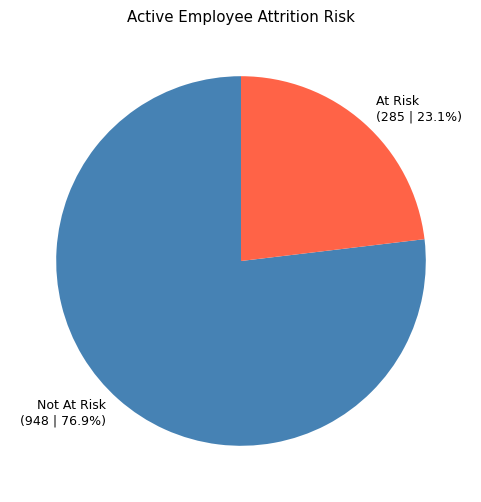

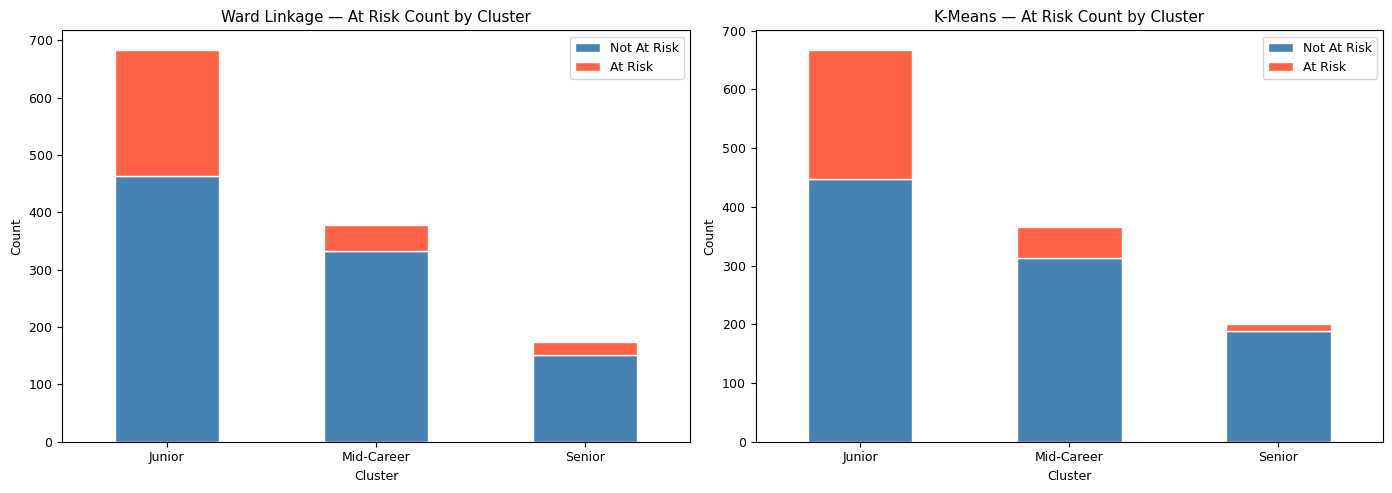

In [40]:
# Create final summary dataframe as a copy of clean_hr_df
final_summary_df = clean_hr_df.copy()

# Add Ward and K-Means cluster labels from hr_df
final_summary_df['cluster_ward'] = hr_df['cluster_ward'].values
final_summary_df['cluster_ward_label'] = hr_df['cluster_ward_label'].values
final_summary_df['cluster_kmeans'] = hr_df['cluster_kmeans'].values
final_summary_df['cluster_kmeans_label'] = hr_df['cluster_kmeans_label'].values

# Add predicted probability of attrition to clean_hr_df
final_summary_df['attrition_probability'] = final_logistic_model.predict_proba(final_X)[:, 1].round(4)

# Add categorical at risk flag based on 50% threshold
final_summary_df['at_risk'] = (final_summary_df['attrition_probability'] >= 0.5).astype(int)

# Filter final summary dataframe to active employees only
final_summary_df = final_summary_df[final_summary_df['Attrition-Yes'] == 0].copy()

# Count at risk and not at risk employees
at_risk_counts = final_summary_df['at_risk'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    at_risk_counts,
    labels=[
        f'Not At Risk\n({at_risk_counts[0]} | {at_risk_counts[0]/at_risk_counts.sum()*100:.1f}%)',
        f'At Risk\n({at_risk_counts[1]} | {at_risk_counts[1]/at_risk_counts.sum()*100:.1f}%)'
    ],
    colors=['steelblue', 'tomato'],
    startangle=90
)
plt.title('Active Employee Attrition Risk')
plt.show()

# Get counts of at risk employees by cluster
at_risk_counts_ward = final_summary_df.groupby('cluster_ward_label')['at_risk'].value_counts().unstack()
at_risk_counts_kmeans = final_summary_df.groupby('cluster_kmeans_label')['at_risk'].value_counts().unstack() 

# Side by side stacked bar charts for at risk counts by cluster and method
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
# Ward linkage at risk count chart
at_risk_counts_ward.plot(
    kind='bar', 
    stacked=True,
    color=['steelblue', 'tomato'],
    edgecolor='white',
    ax=axes[0]
)
axes[0].set_title('Ward Linkage — At Risk Count by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Not At Risk', 'At Risk'])
# K-Means at risk count chart
at_risk_counts_kmeans.plot(
    kind='bar',
    stacked=True,
    color=['steelblue', 'tomato'],
    edgecolor='white',
    ax=axes[1]
)
axes[1].set_title('K-Means — At Risk Count by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Not At Risk', 'At Risk'])
plt.tight_layout()
plt.show()

*Retention Risk Summary*

Based on the model, 23% of employees are at risk for a total of 285. As with the cluster analysis, junior employees have the highest risk level. Targeted efforts should be made to ensure that workloads are balanced and that we reduce travel where possible. 

An effort should also be made to understand why those with a Marketing field of study and / or work in the Sales department are at higher risk for leaving. Once an understanding is reached, an action plan will be put in place to reduce the turnover.

The table below lists employees by risk for attrition. This is an actionable list that can be used for target intervention.

In [41]:
# Build at risk employee summary with probability and key factors
at_risk_summary = final_summary_df[final_summary_df['at_risk'] == 1][[
    'attrition_probability',
    'cluster_ward_label',
    'OverTime-Yes',
    'EducationField-Marketing',
    'Department-Sales',
    'MaritalStatus-Single',
    'BusinessTravel-Non-Travel',
    'EnvironmentSatisfaction'
]].copy()

# Rename columns for readability
at_risk_summary = at_risk_summary.rename(columns={
    'attrition_probability': 'Attrition Probability',
    'cluster_ward_label': 'Career Stage',
    'OverTime-Yes': 'Overtime',
    'EducationField-Marketing': 'Marketing',
    'Department-Sales': 'Sales',
    'MaritalStatus-Single': 'Single',
    'BusinessTravel-Non-Travel': 'Non-Travel',
    'EnvironmentSatisfaction': 'Env Sat'
})

# Sort by highest probability first
at_risk_summary = at_risk_summary.sort_values('Attrition Probability', ascending=False)

print(f'Total at risk employees: {len(at_risk_summary)}')
print(at_risk_summary.to_string())

Total at risk employees: 285
                Attrition Probability Career Stage  Overtime  Marketing  Sales  Single  Non-Travel  Env Sat
EmployeeNumber                                                                                             
732                            0.9879       Junior         0          1      1       1           0        1
72                             0.9817       Junior         1          1      1       0           0        3
1853                           0.9732       Junior         0          1      1       1           0        4
747                            0.9723       Junior         0          1      1       0           0        3
846                            0.9698   Mid-Career         1          1      1       0           0        2
1173                           0.9635       Junior         0          0      0       1           0        4
120                            0.9598   Mid-Career         1          1      1       1           0        3